# GAN vanilla sur SHAPES

Deux reseaux jouent l'un contre l'autre :

1. Generateur `G` : bruit `z` -> fausse image. Il veut tromper `D`.
2. Discriminateur `D` : image -> logit (reelle ou fausse). Il veut ne pas etre trompe.

A l'equilibre, `D` ne fait pas mieux que le hasard et `G` produit des images plausibles.

Le GAN n'a pas d'encodeur : il n'existe aucune fonction `x -> z`. Les trois taches sont traitees
ainsi, la ou deux d'entre elles demandent un detour :

| Tache | Moyen |
|---|---|
| Generation de donnees synthetiques | `generate()` |
| Compression / Decompression | `invert()` puis `decode()`, par descente de gradient sur `z` |
| Projection pour visualisation | `extract_features()`, discriminateur recycle en extracteur |

Les taches 2 et 3 sont evaluees face a une reference : AutoEncoder a dimension latente egale pour
la compression, PCA sur pixels bruts pour la projection.

shapes est plus dur que MNIST sur trois points : couleur (3072 dimensions contre 784), geometrie
a bords francs plutot que des traits, et fond sombre parseme de parasites blancs.

In [1]:
import sys, os
from pathlib import Path

# src/ importable et racine du projet comme dossier courant (les chemins data/ sont relatifs a la racine)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from src.dataset import load_shapes_dataset
from src.gan import GAN
from src.autoencoder import AutoEncoder
from src.pca import PCA
from src.helper import extract_full_dataset, get_device
from src.metrics import compression_report, Latent

np.random.seed(0)
torch.manual_seed(0)
%matplotlib inline

print("device:", get_device())

IMAGE_SHAPE = (3, 32, 32)      # (C, H, W), soit 3072 features une fois aplati
DATA_DIM = int(np.prod(IMAGE_SHAPE))
LATENT_DIM = 100
EPOCHS = 60                    # meme budget que MNIST, pour comparer a configuration egale
BATCH_SIZE = 128
EPOCHS_AE = 150                # l'AE de reference doit avoir converge, cf. tache 2
N_EVAL = 10000                 # N du pipeline partage : ratio comparable a K-Means / PCA
N_PROJECTION = 3000
INVERSION_STEPS = 300

device: mps


In [2]:
def flattened_vector_to_image(flat_vector, image_shape):
    # (D,) -> (H, W) en gris ou (H, W, C) en couleur, pret pour imshow
    channels, height, width = image_shape
    image = flat_vector.reshape(channels, height, width)
    return image[0] if channels == 1 else np.transpose(image, (1, 2, 0))

def show_image_grid(samples, image_shape, n_rows=2, n_cols=8, title=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.3, n_rows * 1.5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(np.clip(flattened_vector_to_image(samples[i], image_shape), 0, 1), cmap=cmap)
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

def show_original_vs_reconstruction_grid(originals, reconstructions, image_shape, n=8, title=None):
    cmap = "gray" if image_shape[0] == 1 else None
    fig, axes = plt.subplots(2, n, figsize=(n * 1.3, 3))
    for i in range(n):
        axes[0, i].imshow(np.clip(flattened_vector_to_image(originals[i], image_shape), 0, 1), cmap=cmap)
        axes[1, i].imshow(np.clip(flattened_vector_to_image(reconstructions[i], image_shape), 0, 1), cmap=cmap)
        axes[0, i].axis("off"); axes[1, i].axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout(); plt.show()

## Partie A - Dataset SHAPES

Pipeline partage du projet, a l'identique : `load_shapes_dataset` sur le sous-dossier `train`,
`extract_full_dataset`, puis les 10000 premieres images aplaties a la volee.

Deux points de vigilance. Le loader vise `data/shapes_hard_color/train` et non la racine : pointe
sur la racine il detecte `['train', 'validation']` comme classes. Et le `shuffle=True` avec
`torch.manual_seed(0)` fixe le sous-ensemble : les effectifs par forme ci-dessous doivent etre
identiques a ceux de `01_kmeans_shapes.ipynb`, sinon les MSE et les ratios ne sont pas comparables
entre algorithmes.

X: (10000, 3072) float32 | pixels dans [ 0.0 , 1.0 ]
formes : ['bar', 'circle', 'cross', 'square', 'star', 'triangle']
effectifs par forme : [1610, 1691, 1686, 1656, 1726, 1631]


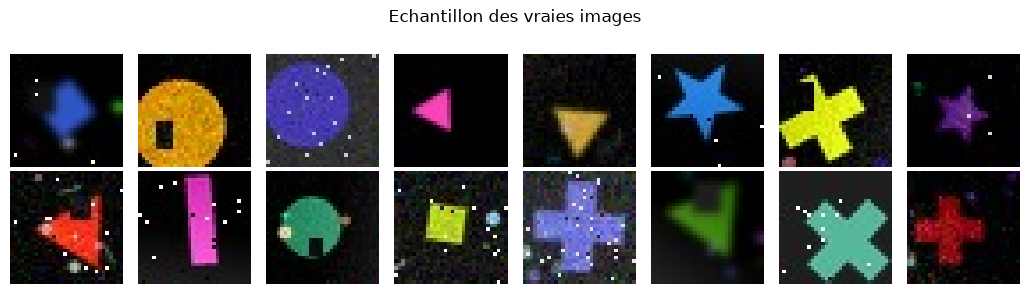

In [3]:
torch.manual_seed(0)
dataloader = load_shapes_dataset(data_dir="data/shapes_hard_color/train", batch_size=4096, shuffle=True)
images, shape_labels = extract_full_dataset(dataloader)

class_names = list(dataloader.dataset.classes)

# images : (N, C, H, W) -> aplati a la volee, comme impose par le contrat d'interface
X = images[:N_EVAL].flatten(start_dim=1).numpy().astype(np.float32)
y = shape_labels[:N_EVAL].numpy()

print("X:", X.shape, X.dtype, "| pixels dans [", X.min(), ",", X.max(), "]")
print("formes :", class_names)
print("effectifs par forme :", np.bincount(y).tolist())
show_image_grid(X, IMAGE_SHAPE, title="Echantillon des vraies images")

### Protocole d'entrainement

Chaque batch enchaine deux pas de descente de gradient.

**1. Pas sur `D`** (vraies -> 1, fausses -> 0). `G` doit rester fige : le batch genere passe par
`.detach()`, qui coupe le graphe et empeche le gradient de remonter jusqu'a ses poids.

**2. Pas sur `G`** (fausses -> 1, du point de vue de `D`). Symetriquement, `D` est gele via
`set_requires_grad(discriminator, False)`. Le gradient doit **traverser** `D` pour atteindre `G`,
mais ne doit pas modifier ses poids.

**Loss et saturation.** La formulation d'origine fait minimiser `log(1 - D(G(z)))` a `G`. Quand `D`
rejette une fausse image avec confiance, la derivee de ce terme tend vers 0 : `G` cesse d'apprendre
precisement quand il est le plus mauvais. On utilise donc la forme **non saturante**, `G` maximise
`log D(G(z))`, ce qui s'ecrit `BCE(D(fake), 1)`. `BCEWithLogitsLoss` est prefere a
`Sigmoid + BCELoss` : le log-sum-exp est calcule de facon stable, un logit tres confiant ne produit
pas un gradient nul par arrondi.

**Handicap de `D`.** `Dropout(0.3)` entre ses couches cachees. Sans lui, `D` gagne la partie trop
vite sur MNIST et `G` n'a plus de gradient (`journal_dev_gan.md`, 16/07 15:30). On garde ce reglage
ici, la configuration devant rester celle de MNIST.

**Sampling.** Batchs melanges (`shuffle=True`) : tries par classe, ils donneraient a `D` une
statistique de lot a exploiter au lieu de juger chaque image. `drop_last=True` ecarte le dernier
batch incomplet, qui fausserait les moyennes de fin d'epoch. Les images sont mises a l'echelle de
`[0, 1]` vers `[-1, 1]` en interne pour correspondre au Tanh de sortie de `G`.

Pas de split train/eval pour l'entrainement : il n'y a pas de reconstruction a valider. Le split
reapparait a la tache 2, ou l'on inverse des images pour mesurer une MSE.

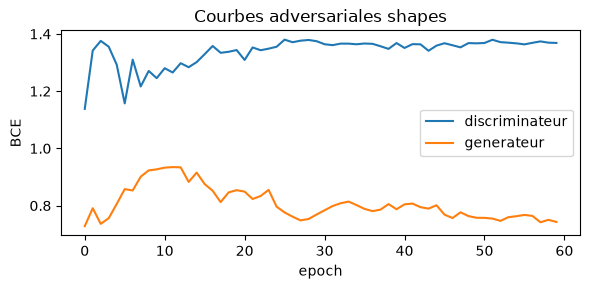

loss finale D: 1.368 | loss finale G: 0.743


In [4]:
np.random.seed(0); torch.manual_seed(0)

# GAN(data_dim, latent_dim) : G [100 -> 256 -> 512 -> 1024 -> 3072], D [3072 -> 512 -> 256 -> 1]
gan = GAN(data_dim=DATA_DIM, latent_dim=LATENT_DIM)
gan.fit(X, epochs=EPOCHS, batch_size=BATCH_SIZE)

plt.figure(figsize=(6, 3))
plt.plot(gan.loss_history["discriminator"], label="discriminateur")
plt.plot(gan.loss_history["generator"], label="generateur")
plt.xlabel("epoch"); plt.ylabel("BCE"); plt.title("Courbes adversariales shapes")
plt.legend(); plt.tight_layout(); plt.show()

print("loss finale D:", round(gan.loss_history["discriminator"][-1], 3),
      "| loss finale G:", round(gan.loss_history["generator"][-1], 3))

### Lecture des courbes

Une loss qui descend n'est pas un bon signe : les deux reseaux optimisent des objectifs opposes,
la somme ne peut pas tendre vers zero.

- Les deux courbes oscillent autour d'un plateau : le jeu est equilibre.
- La loss de `D` tombe vers 0 et celle de `G` explose : `D` a gagne, `G` n'a plus de gradient.
- La loss de `G` s'effondre : `G` a trouve une faille, souvent un signe de mode collapse.

Ici la loss de `D` monte de 1.14 a **1.37** et plafonne, celle de `G` oscille entre 0.74 et 0.93
sans exploser. Les deux courbes se stabilisent et aucun des trois scenarios ci-dessus ne se
declenche : la partie est equilibree.

Ce que ces courbes ne disent pas, c'est ce que `G` produit. On y vient.

### Metriques d'equilibre

Les loss seules ne disent pas si la partie est equilibree. Deux indicateurs le disent :

- **accuracy de `D`** sur un lot moitie vraies moitie fausses. A 0.5, `D` ne fait pas mieux que le
  hasard : `G` produit des images qu'il ne sait plus distinguer des vraies.
- **variance des images generees** au sein d'un batch. Elle doit rester elevee ; un effondrement
  signale un mode collapse.

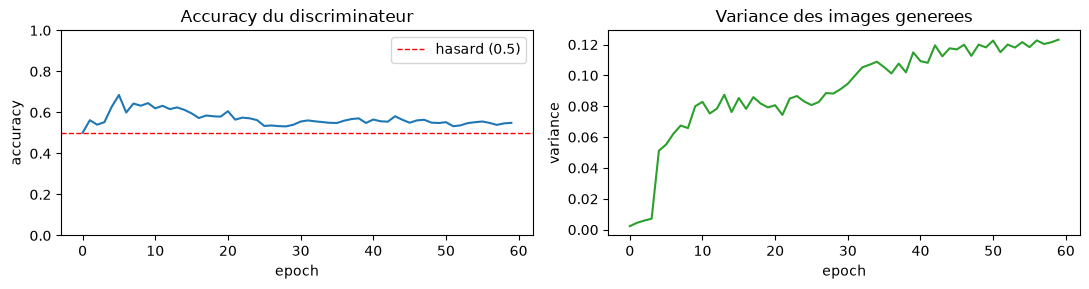

accuracy finale de D: 0.549
variance finale de G: 0.1232


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

axes[0].plot(gan.metric_history["discriminator_accuracy"])
axes[0].axhline(0.5, color="red", ls="--", lw=1, label="hasard (0.5)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy"); axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy du discriminateur"); axes[0].legend()

axes[1].plot(gan.metric_history["generator_variance"], color="tab:green")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("variance")
axes[1].set_title("Variance des images generees")

plt.tight_layout(); plt.show()

print("accuracy finale de D:", round(gan.metric_history["discriminator_accuracy"][-1], 3))
print("variance finale de G:", round(gan.metric_history["generator_variance"][-1], 4))

Les deux metriques sont **bonnes**, et meilleures que sur MNIST : l'accuracy de `D` se cale a
**0.549**, presque le 0.5 vise (contre 0.63 sur MNIST), et la variance de `G` monte de 0.002 a
**0.123** puis se stabilise, donc pas d'effondrement.

Lues seules, elles disent que la partie est mieux equilibree ici que sur MNIST. Elles ne disent rien
de la qualite des images.

Precision de mesure : l'accuracy est relevee pendant l'entrainement, `Dropout` actif. Elle
sous-estime donc le pouvoir discriminant reel de `D`, qui serait plus eleve en `eval()`.

## Tache 1 - Generation de donnees synthetiques

shape: (16, 3072) | valeurs dans (0.0, 0.996)


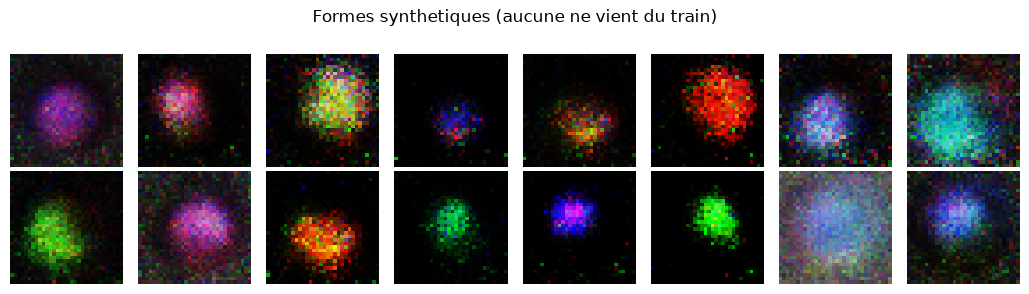

In [6]:
# generate(n, seed) -> (n, 3072), float32 dans [0, 1]
fake = gan.generate(16, seed=0)
print("shape:", fake.shape, "| valeurs dans", (round(float(fake.min()), 3), round(float(fake.max()), 3)))
show_image_grid(fake, IMAGE_SHAPE, title="Formes synthetiques (aucune ne vient du train)")

### Verification du mode collapse

Risque : `G` trouve une image qui trompe `D` et ne produit plus qu'elle. On genere un lot large et
on compare l'ecart-type pixel a pixel entre images a celui des vraies donnees.

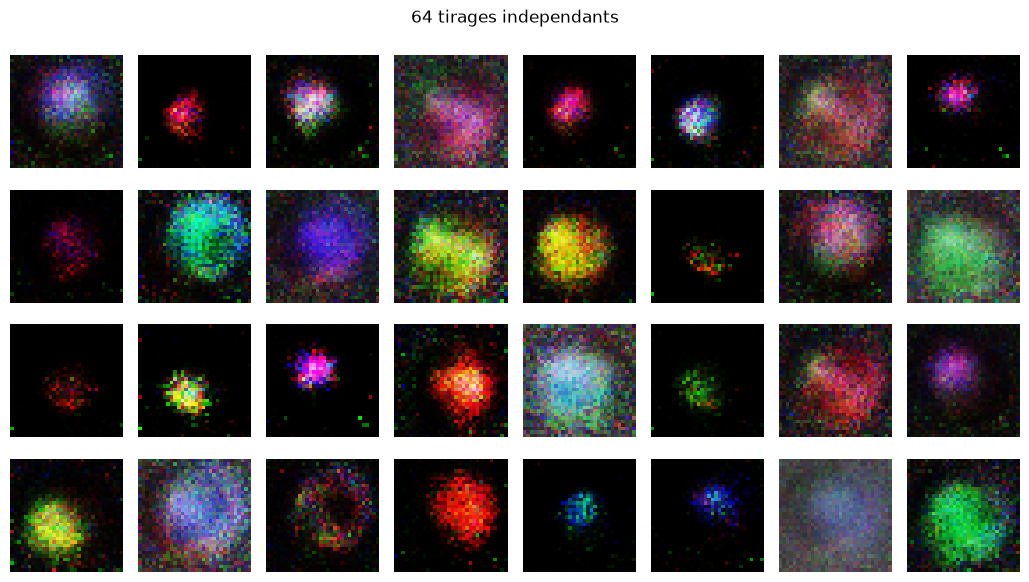

ecart-type inter-images (genere): 0.1595


ecart-type inter-images (reel)  : 0.1765


In [7]:
sample_batch = gan.generate(64, seed=1)
show_image_grid(sample_batch, IMAGE_SHAPE, n_rows=4, n_cols=8, title="64 tirages independants")

print("ecart-type inter-images (genere):", round(float(sample_batch.std(axis=0).mean()), 4))
print("ecart-type inter-images (reel)  :", round(float(X.std(axis=0).mean()), 4))

Ecart-type inter-images **0.1595 contre 0.1765** au reel, soit 90% de la diversite des vraies
donnees, et la variance de `G` etait stable pendant tout l'entrainement. **Pas de mode collapse** :
les 64 tirages sont bien distincts, les couleurs, les tailles et les positions varient.

Ce qui isole proprement le probleme : les images ne sont pas peu variees, elles sont **variees et
fausses**. Aucune ne presente de bord franc ni de geometrie identifiable, la ou les vraies images
sont des polygones nets sur fond sombre.

### Structure de l'espace latent

Interpolation lineaire entre deux bruits `z_a` et `z_b`, chaque etape decodee. Des images plausibles
tout au long du chemin indiquent une variete continue apprise, et non une memorisation du train.

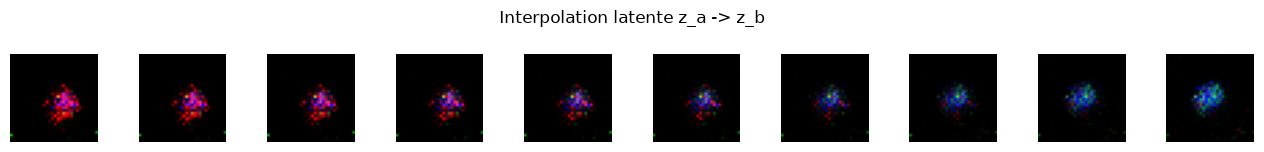

In [8]:
def interpolate_latent(gan, n_steps=10, seed=2):
    # -> (n_steps, data_dim) : chemin de z_a vers z_b decode par le generateur
    torch.manual_seed(seed)
    z_a, z_b = gan.sample_noise(1), gan.sample_noise(1)
    weights = torch.linspace(0, 1, n_steps, device=gan.device).unsqueeze(1)
    path = (1 - weights) * z_a + weights * z_b
    return gan.decode(Latent(array=path.cpu().numpy(), nature="continuous"))

walk = interpolate_latent(gan, n_steps=10)
show_image_grid(walk, IMAGE_SHAPE, n_rows=1, n_cols=10, title="Interpolation latente z_a -> z_b")

### Diagnostic : les metriques d'equilibre ne mesurent pas la qualite

L'interpolation est continue, une tache rouge se deforme progressivement en tache bleue sans
discontinuite : `G` a bien appris une variete continue, mais c'est une **variete de taches**. Il n'y
a pas de memorisation du train, il n'y a pas non plus de forme.

**Verdict de la tache 1 : echec sur ce dataset.** Ce que `G` a appris est reel mais partiel : la
palette de couleurs, le fond sombre, un objet unique et compact au centre. Ce qu'il n'a pas appris,
c'est la **geometrie** : aucune des six formes n'est identifiable. Le contraste avec MNIST est net,
ou la meme configuration produisait des chiffres reconnaissables et varies.

Le point de methode est la, et il est plus interessant que le verdict : ce notebook affiche les
**meilleures metriques d'equilibre** de tout le projet GAN (accuracy 0.549, quasi le 0.5 ideal, pas
de collapse) et produit les **pires images**. Les metriques d'equilibre disent que `D` et `G` sont a
egalite, pas que `G` est bon. Ici l'egalite est obtenue **par le bas**.

Le vrai signal etait sous nos yeux : `D` plafonne a 0.549 d'accuracy sur des faux qu'un humain
rejette au premier coup d'oeil. Ce n'est pas que `G` est bon, c'est que **`D` est aveugle**. Un MLP
recoit 3072 pixels sans aucune notion de voisinage : il n'a pas de quoi representer un bord. Il juge
donc sur des statistiques de couleur, et `G` n'a qu'a les reproduire pour gagner. Sur MNIST cela
suffisait, les traits blancs sur fond noir etant largement portes par ces statistiques ; ici la
geometrie ne l'est pas.

Le reflexe herite de MNIST serait de corriger un desequilibre en affaiblissant `D`
(`journal_dev_gan.md`, 16/07 15:30). Il ne s'applique pas : le probleme n'est ni l'equilibre ni la
duree, il est **representationnel**. Le manque est un prior spatial, donc des convolutions ; cette
piste sort du GAN vanilla et est traitee dans `06_gan_shapes.ipynb`.

## Tache 2 - Compression / Decompression

Le generateur est un decodeur `z -> x`, mais rien ne code une image existante. Pour obtenir son
code latent il faut le **chercher** : `G` est fige et une descente de gradient est menee sur `z`
lui-meme pour minimiser `||G(z) - x||`. C'est `GAN.invert()`.

Ce n'est pas un encodeur : l'AutoEncoder code une image en une passe avant, ici il faut 300 pas de
gradient.

`N_EVAL = 10000`, soit le N du pipeline partage. Ce choix est delibere : le codebook est un cout
fixe amorti sur N, donc le ratio de compression n'a de sens entre algorithmes que si le N est le
meme. C'est le N sur lequel `01_kmeans_shapes.ipynb` et `02_pca_shapes.ipynb` publient leurs
chiffres. Corollaire : le ratio ci-dessous n'est **pas** comparable a celui de `06_gan.ipynb`, qui
mesure sur 1000 images.

code latent par image: 100 valeurs | nature: continuous


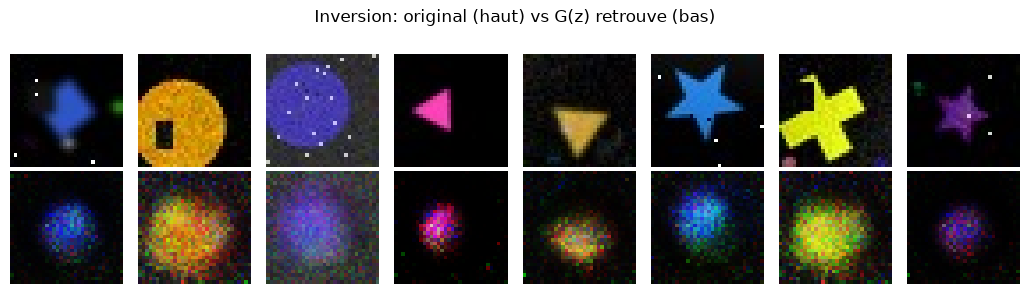

In [9]:
# invert(X, steps, seed) -> Latent de shape (N, latent_dim), nature "continuous"
gan_latent = gan.invert(X, steps=INVERSION_STEPS, seed=0)
gan_reconstructed = gan.decode(gan_latent)
print("code latent par image:", gan_latent.array.shape[1], "valeurs | nature:", gan_latent.nature)

show_original_vs_reconstruction_grid(X, gan_reconstructed, IMAGE_SHAPE, n=8,
                     title="Inversion: original (haut) vs G(z) retrouve (bas)")

L'inversion echoue, et elle echoue de la meme facon que la generation : les reconstructions sont des
**taches**. Elles retrouvent la couleur dominante, la taille et la position approximative de l'objet,
jamais sa forme. Un losange bleu devient une tache bleue, une croix jaune une tache jaune, une etoile
violette une tache violette.

C'est la mesure la plus tranchante du notebook, et elle est plus forte que le verdict de la tache 1.
L'inversion est une descente de gradient de 300 pas **dediee a une seule image** : si un `z` capable
de produire cette croix existait dans l'espace latent, l'optimisation aurait toutes les chances de le
trouver. Elle ne le trouve pas. Aucune des six geometries n'a d'antecedent dans l'espace latent : ce
n'est pas le tirage de `z` qui est en cause, c'est `G` qui **ne sait pas produire une forme**, quel
que soit `z`.

Contraste avec MNIST : la meme inversion y retrouvait la plupart des chiffres, seuls quelques-uns
degeneraient en tache (mode dropping partiel). Ici le mode dropping est total sur la geometrie.

In [10]:
gan_report = compression_report(gan.get_codebook(), gan_latent, X, gan_reconstructed)

# Reference a dimension latente identique (100), pour que la comparaison porte sur le modele.
# L'AE est entraine jusqu'a convergence : a 15 epochs (le budget du notebook MNIST) il n'a pas fini
# d'apprendre sur shapes, et le GAN paraitrait meilleur (journal_dev_gan.md, 17/07 12:20).
np.random.seed(0); torch.manual_seed(0)
autoencoder = AutoEncoder(
    input_dim=DATA_DIM, output_dim=DATA_DIM, latent_dim=LATENT_DIM,
    encoder_layer_num=3, decoder_layer_num=3, encoder_activation=nn.ReLU, fonction_loss=nn.MSELoss
)
autoencoder.fit(X, epochs=EPOCHS_AE, batch_size=BATCH_SIZE)
ae_latent = autoencoder.encode(X)
ae_reconstructed = autoencoder.decode(ae_latent)
ae_report = compression_report(autoencoder.get_codebook(), ae_latent, X, ae_reconstructed)

print(f"{'critere':<26}{'GAN':>14}{'AutoEncoder':>16}")
for key in ["reconstruction_mse", "codebook_bytes", "latent_bytes", "compression_ratio"]:
    fmt = lambda v: f"{v:.5f}" if isinstance(v, float) else str(v)
    print(f"{key:<26}{fmt(gan_report[key]):>14}{fmt(ae_report[key]):>16}")

critere                              GAN     AutoEncoder
reconstruction_mse               0.01866         0.00477
codebook_bytes                  15326208        13411860
latent_bytes                     4000000         4000000
compression_ratio                6.35821         7.05726


### Lecture

Le GAN est **domine sur les deux axes**, ce qui n'etait pas le cas sur MNIST (ou il perdait la
qualite mais avec un codebook du meme ordre).

**1. Qualite.** MSE **0.01866 contre 0.00477** pour l'AutoEncoder, soit **3.9x pire** a dimension
latente egale. L'ecart est coherent avec les images : l'AE reconstruit des formes, le GAN des taches.

**2. Poids du codebook.** Les poids de `G` pesent **15.3 Mo contre 13.4 Mo** pour le decodeur de
l'AE. Le GAN est donc aussi plus lourd, et son ratio est inferieur : **6.36 contre 7.06**. Il n'a
aucun avantage a faire valoir ici.

Le cout, lui, ne se lit pas dans le tableau : les 100 valeurs latentes du GAN demandent **300 pas de
gradient par image** a l'encodage, la ou l'AE fait une seule passe avant.

Point de methode, qui a failli produire une conclusion fausse : l'AE est ici entraine **150 epochs**.
Avec les 15 epochs du notebook MNIST il n'a pas converge sur shapes et le GAN s'en rapprocherait,
ce qui ne mesurerait qu'un budget inegal (`journal_dev_gan.md`, 17/07 12:20). Une reference
sous-entrainee n'est pas une reference.

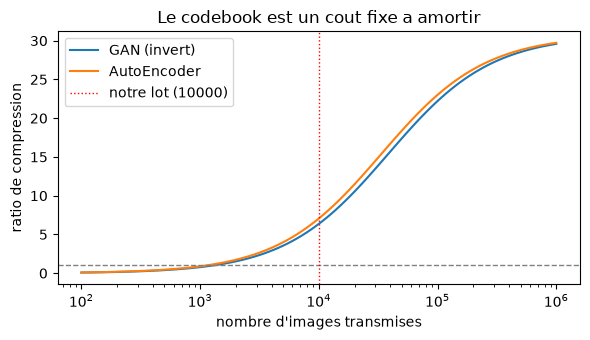

le GAN devient rentable au-dela de 1289 images
plafond theorique (codebook amorti): 30.72


In [11]:
def compression_ratio_curve(codebook_bytes, latent_dim, data_dim, n_images):
    # -> (len(n_images),) : ratio original / (codebook + latent) en fonction du nombre d'images
    original = n_images * data_dim * 4
    compressed = codebook_bytes + n_images * latent_dim * 4
    return original / compressed

n_images = np.logspace(2, 6, 100)
plt.figure(figsize=(6, 3.5))
for label, report in [("GAN (invert)", gan_report), ("AutoEncoder", ae_report)]:
    plt.plot(n_images, compression_ratio_curve(report["codebook_bytes"], LATENT_DIM, DATA_DIM, n_images), label=label)
plt.axhline(1, color="grey", ls="--", lw=1)
plt.axvline(N_EVAL, color="red", ls=":", lw=1, label=f"notre lot ({N_EVAL})")
plt.xscale("log"); plt.xlabel("nombre d'images transmises"); plt.ylabel("ratio de compression")
plt.title("Le codebook est un cout fixe a amortir")
plt.legend(); plt.tight_layout(); plt.show()

# Seuil de rentabilite : ratio = 1, soit codebook = N * (gain par image)
print("le GAN devient rentable au-dela de",
      int(gan_report["codebook_bytes"] / ((DATA_DIM - LATENT_DIM) * 4)), "images")
print("plafond theorique (codebook amorti):", round(DATA_DIM / LATENT_DIM, 2))

Le seuil de rentabilite tombe a **1289 images** (contre environ 2170 sur MNIST) : le gain par image
est bien plus grand, 3072 valeurs remplacees par 100. Sur notre lot de 10000 le ratio vaut 6.36, a
comparer au plafond de **30.72** vers lequel la courbe tend une fois le codebook amorti.

La courbe montre surtout que l'AutoEncoder reste **au-dessus du GAN sur toute la plage** : son
codebook est plus leger, l'ecart ne se resorbe jamais. Contrairement a MNIST, il n'y a pas de regime
ou le GAN devient le meilleur choix en compression.

## Tache 3 - Projection pour visualisation

Le generateur ne projette rien. Le discriminateur, lui, prend une image en entree et s'est
construit des descripteurs internes pour juger du vrai/faux : ses couches peuvent servir
d'extracteur de features, usage introduit par Radford et al. (DCGAN, 2016).

`extract_features()` renvoie la derniere couche cachee de `D` (256 dimensions), projetee ensuite en
2D par PCA. Reference : PCA appliquee directement aux pixels bruts.

features de D: (3000, 256)


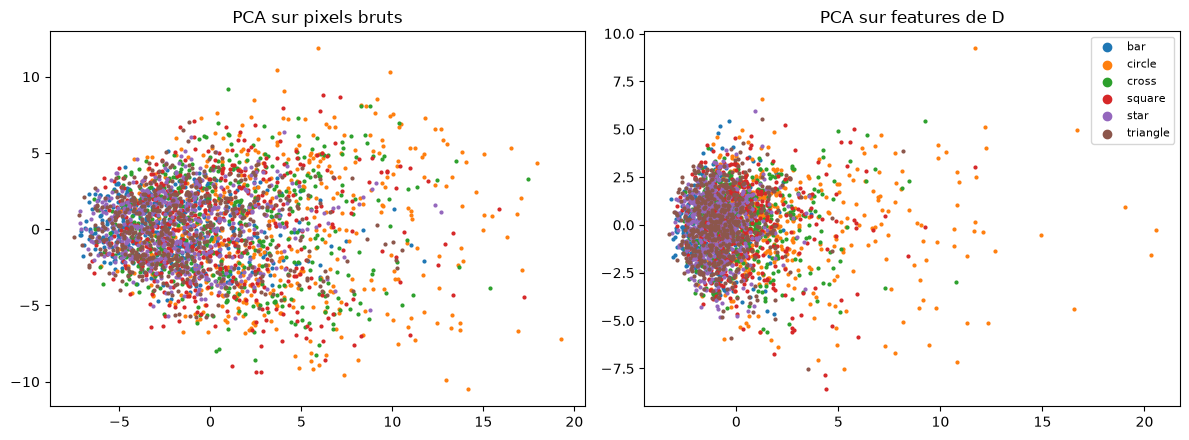

In [12]:
X_proj, y_proj = X[:N_PROJECTION], y[:N_PROJECTION]

# extract_features(X) -> (N, 256) : derniere couche cachee de D
discriminator_features = gan.extract_features(X_proj)
print("features de D:", discriminator_features.shape)

z_features = PCA(n_components=2).fit(discriminator_features).encode(discriminator_features).array
z_pixels = PCA(n_components=2).fit(X_proj).encode(X_proj).array

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, projection, title in [(axes[0], z_pixels, "PCA sur pixels bruts"),
                              (axes[1], z_features, "PCA sur features de D")]:
    for label, name in enumerate(class_names):
        mask = y_proj == label
        ax.scatter(projection[mask, 0], projection[mask, 1], s=4, label=name)
    ax.set_title(title)
axes[1].legend(markerscale=3, fontsize=8)
plt.tight_layout(); plt.show()

Les couleurs sont les vraies etiquettes, jamais vues par le GAN : elles ne servent qu'a juger
la projection a posteriori. Separabilite quantifiee par un kNN entraine sur les 2 composantes.

In [13]:
for name, projection in [("pixels bruts", z_pixels), ("features de D", z_features)]:
    accuracy = cross_val_score(KNeighborsClassifier(15), projection, y_proj, cv=3).mean()
    print(f"kNN sur 2 composantes ({name:<14}): {accuracy:.3f}")
print(f"{'hasard (6 formes equilibrees)':<37}: {1/6:.3f}")

kNN sur 2 composantes (pixels bruts  ): 0.245
kNN sur 2 composantes (features de D ): 0.249
hasard (6 formes equilibrees)        : 0.167


### Lecture

Les features de `D` obtiennent **0.249 contre 0.245** pour les pixels bruts. L'ecart est dans le
bruit de la validation croisee : le detour ne rattrape rien. Sur MNIST les features faisaient
legerement moins bien (0.430 contre 0.441), ici legerement mieux ; dans les deux cas le
discriminateur n'apporte rien, et pour la meme raison. Il a ete entraine a separer "reelle" de
"fausse", pas a separer les formes : rien dans sa loss ne l'encourage a distinguer un carre d'une
etoile, les deux etant de vraies images.

Le second enseignement est plus large : **les deux projections sont proches du hasard** (0.167). En
2 composantes, la forme geometrique n'est pas separable, quelle que soit la representation. Les deux
nuages sont d'ailleurs visuellement identiques, une masse unique sans structure par classe, etiree
par les quelques `circle` de grande taille. La variance dominante de ce dataset est portee par la
couleur, la taille et la position de l'objet, pas par sa geometrie.

Recoupement avec les chiffres publies sur le meme lot dans `01_kmeans_shapes.ipynb` : un K-Means a
`k = 6` atteint 26.29% de precision forme, le meme ordre de grandeur. La difficulte vient donc du
dataset et non du seul GAN.

Verdict : non adapte.

## Synthese

Mesures sur les 10000 images du pipeline partage, dimension latente 100 pour le GAN comme pour
l'AutoEncoder de reference.

| Tache | Verdict | Mesure |
|---|---|---|
| Generation | Echec sur la geometrie | Couleur, fond et position appris, aucune des 6 formes identifiable. Diversite intacte (ecart-type inter-images 0.1595 contre 0.1765 au reel), donc ce n'est pas un mode collapse |
| Compression | Echec | MSE 0.01866 contre 0.00477 pour l'AE, ratio 6.36 contre 7.06. Domine sur la qualite et sur le poids. Cout : 300 pas de gradient par image a l'encodage |
| Projection | Non adapte | kNN 0.249 sur les features de `D` contre 0.245 sur les pixels bruts, pour un hasard a 0.167 |

Le GAN vanilla **echoue sur les trois taches** sur ce dataset, alors que la meme configuration
reussissait la generation sur MNIST. La cause est unique et elle est mesuree deux fois : `G` ne
produit aucune geometrie. La tache 1 le montre en tirant `z` dans le prior ; la tache 2 le confirme
plus durement, une descente de gradient de 300 pas dediee a une image donnee ne retrouve pas
davantage sa forme. Aucune des six geometries n'a d'antecedent dans l'espace latent.

Deux lecons de methode, payees par les mesures de ce notebook :

1. **Les metriques d'equilibre ne mesurent pas la qualite.** Ce notebook affiche l'accuracy de `D`
   la plus proche de 0.5 de tout le projet (0.549) et produit les pires images. L'egalite peut etre
   obtenue par le bas, avec un `D` trop faible pour voir.
2. **Une correction n'est valable que contre la pathologie qu'elle vise.** Le correctif qui a sauve
   MNIST, affaiblir `D` par du dropout, ne repond pas a ce probleme-ci : `D` n'est pas trop fort, il
   est aveugle. Un MLP n'a aucune notion de voisinage, donc aucun moyen de representer un bord.